# Modelleme

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)

## 1. Veri Yükleme

In [17]:
df = pd.read_csv("../data/processed/processed.csv")
print(df.shape)
df.head()

(19991, 17)


,log_market_value,age,height_in_cm,total_goals,total_assists,total_matches,total_yellow_cards,total_red_cards,goals_per_match,assists_per_match,minutes_per_match,position,position_encoded,sub_position_encoded,foot_encoded,country_of_citizenship_encoded,player_club_domestic_competition_id_encoded
0,12.206078,1.301434,-0.938316,0.018438,0.061233,2.507168,2.607541,-0.402163,-0.402793,-0.409267,0.624499,Midfield,3,4,1,61,11
1,14.508658,0.891000,-0.938316,3.677642,6.671520,3.377080,0.612516,-0.402163,1.250323,2.353707,0.105545,Midfield,3,0,2,59,15
2,12.206078,1.506650,1.008081,-0.388140,-0.453855,0.075875,-0.384997,1.208343,-0.642263,-0.687434,1.319252,Goalkeeper,2,5,1,144,8
3,12.611541,1.506650,-0.339425,1.644751,0.490472,1.336132,0.945020,1.208343,1.220282,0.105856,-0.168671,Attack,0,3,2,125,21
4,12.206078,1.711867,1.008081,-0.388140,-0.453855,-0.314470,-0.052493,1.208343,-0.642263,-0.687434,1.376074,Defender,1,2,1,115,24


## 2. Girdi ve Çıktı Ayrımı

In [18]:
# girdi ve çıktı ayarlama
X = df.drop(columns=["log_market_value", "position"])
y = df["log_market_value"]

print("Veri boyutu:", X.shape)

Veri boyutu: (19991, 15)


## 3. Eğitim ve Test Ayrımı

In [19]:
# %80 eğitim, %20 test ayırma
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Eğitim seti:", X_train.shape)
print("Test seti:", X_test.shape)

Eğitim seti: (15992, 15)
Test seti: (3999, 15)


## 4. Model 1: Doğrusal Regresyon (Linear Regression)

In [20]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Sonuçları:")
print(f"MAE: {mae_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print(f"R²: {r2_lr:.4f}")

Linear Regression Sonuçları:
MAE: 0.8337
RMSE: 1.0491
R²: 0.4772


## 5. Model 2: Rastgele Orman Regresörü (Random Forest Regressor)

In [21]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Sonuçları:")
print(f"MAE: {mae_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R²: {r2_rf:.4f}")

Random Forest Sonuçları:
MAE: 0.6259
RMSE: 0.8053
R²: 0.6920


## 6. Mevkiye Göre Modelleme

In [22]:
# mevki tabanlı kıyaslama
position_features = {
    "Goalkeeper": [
        "age", "height_in_cm", "total_matches", "minutes_per_match",
        "total_yellow_cards", "total_red_cards",
        "position_encoded", "foot_encoded",
        "country_of_citizenship_encoded", "player_club_domestic_competition_id_encoded"
    ],
    "Defender": [
        "age", "height_in_cm", "total_matches", "minutes_per_match",
        "total_yellow_cards", "total_red_cards",
        "position_encoded", "sub_position_encoded", "foot_encoded",
        "country_of_citizenship_encoded", "player_club_domestic_competition_id_encoded"
    ],
    "Midfield": [
        "age", "total_goals", "total_assists", "total_matches",
        "goals_per_match", "assists_per_match", "minutes_per_match",
        "total_yellow_cards", "total_red_cards",
        "position_encoded", "sub_position_encoded", "foot_encoded",
        "country_of_citizenship_encoded", "player_club_domestic_competition_id_encoded"
    ],
    "Attack": [
        "age", "total_goals", "total_assists", "total_matches",
        "goals_per_match", "assists_per_match", "minutes_per_match",
        "total_yellow_cards", "total_red_cards",
        "sub_position_encoded", "foot_encoded",
        "country_of_citizenship_encoded", "player_club_domestic_competition_id_encoded"
    ]
}

positions = df["position"].unique()
position_results = []
position_models = {}

for position in sorted(positions):
    df_pos = df[df["position"] == position].copy()
    X_pos = df_pos[position_features[position]]
    y_pos = df_pos["log_market_value"]

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_pos, y_pos, test_size=0.2, random_state=42
    )

    lr_pos = LinearRegression()
    lr_pos.fit(X_tr, y_tr)
    y_pred_lr_pos = lr_pos.predict(X_te)
    cv_lr_pos = np.sqrt(-cross_val_score(
        lr_pos, X_tr, y_tr, cv=5, scoring="neg_mean_squared_error"
    ))

    rf_pos = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_pos.fit(X_tr, y_tr)
    y_pred_rf_pos = rf_pos.predict(X_te)
    cv_rf_pos = np.sqrt(-cross_val_score(
        rf_pos, X_tr, y_tr, cv=5, scoring="neg_mean_squared_error"
    ))

    position_results.append({
        "Mevki": position,
        "LR RMSE": np.sqrt(mean_squared_error(y_te, y_pred_lr_pos)),
        "RF RMSE": np.sqrt(mean_squared_error(y_te, y_pred_rf_pos)),
        "LR MAE": mean_absolute_error(y_te, y_pred_lr_pos),
        "RF MAE": mean_absolute_error(y_te, y_pred_rf_pos),
        "LR R²": r2_score(y_te, y_pred_lr_pos),
        "RF R²": r2_score(y_te, y_pred_rf_pos),
        "LR CV RMSE": cv_lr_pos.mean(),
        "RF CV RMSE": cv_rf_pos.mean()
    })
    position_models[position] = {"lr": lr_pos, "rf": rf_pos}
    print(f"{position:12} | LR R²: {position_results[-1]['LR R²']:.4f} | RF R²: {position_results[-1]['RF R²']:.4f}")

position_df = pd.DataFrame(position_results)
print()
print(position_df.to_string(index=False))

Attack       | LR R²: 0.4421 | RF R²: 0.6493
Defender     | LR R²: 0.4531 | RF R²: 0.6623
Goalkeeper   | LR R²: 0.4194 | RF R²: 0.6268
Midfield     | LR R²: 0.5120 | RF R²: 0.6761

     Mevki  LR RMSE  RF RMSE   LR MAE   RF MAE    LR R²    RF R²  LR CV RMSE  RF CV RMSE
    Attack 1.059238 0.839835 0.837109 0.650856 0.442087 0.649274    1.049188    0.867083
  Defender 1.020918 0.802174 0.817867 0.634671 0.453079 0.662339    1.024916    0.824413
Goalkeeper 1.079224 0.865238 0.838884 0.679430 0.419448 0.626846    0.999443    0.823895
  Midfield 1.024146 0.834404 0.807121 0.647096 0.512009 0.676078    1.043529    0.853881


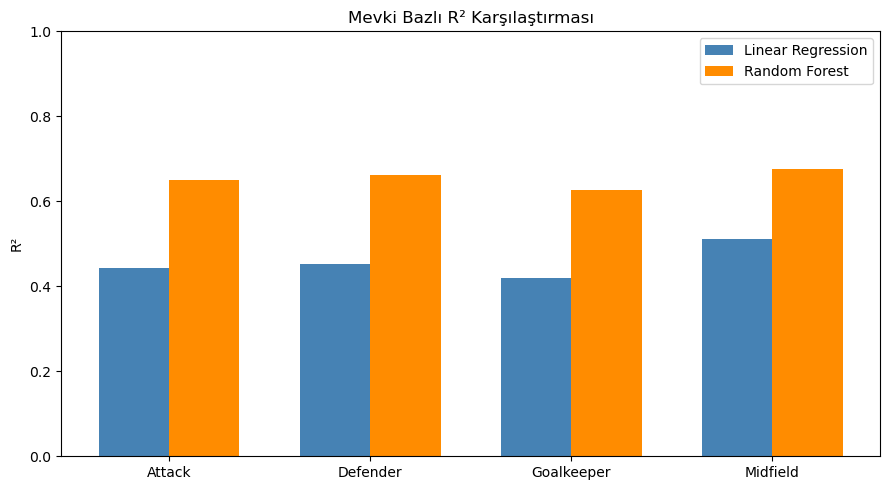

In [23]:
x = range(len(position_df))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar([i - width/2 for i in x], position_df["LR R²"], width, label="Linear Regression", color="steelblue")
ax.bar([i + width/2 for i in x], position_df["RF R²"], width, label="Random Forest", color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(position_df["Mevki"])
ax.set_ylabel("R²")
ax.set_title("Mevki Bazlı R² Karşılaştırması")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig("../visuals/position_r2.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Çapraz Doğrulama (Cross Validation)

In [24]:
# 5 katlı çapraz doğrulama (negatif MSE -> RMSE)
cv_rmse_lr = np.sqrt(-cross_val_score(
    lr, X_train, y_train, cv=5, scoring="neg_mean_squared_error"
))

cv_rmse_rf = np.sqrt(-cross_val_score(
    rf, X_train, y_train, cv=5, scoring="neg_mean_squared_error"
))

print("Linear Regression CV RMSE: {:.4f} ± {:.4f}".format(
    cv_rmse_lr.mean(), cv_rmse_lr.std()))
print("Random Forest CV RMSE: {:.4f} ± {:.4f}".format(
    cv_rmse_rf.mean(), cv_rmse_rf.std()))

Linear Regression CV RMSE: 1.0369 ± 0.0141
Random Forest CV RMSE: 0.7967 ± 0.0213


## 8. Model Karşılaştırması

In [25]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R²": [r2_lr, r2_rf],
    "CV RMSE": [cv_rmse_lr.mean(), cv_rmse_rf.mean()],
    "CV Std": [cv_rmse_lr.std(), cv_rmse_rf.std()]
})

print(results.to_string(index=False))

            Model      MAE     RMSE       R²  CV RMSE   CV Std
Linear Regression 0.833678 1.049129 0.477233  1.03690 0.014133
    Random Forest 0.625892 0.805345 0.691955  0.79669 0.021293


## 9. Görselleştirme

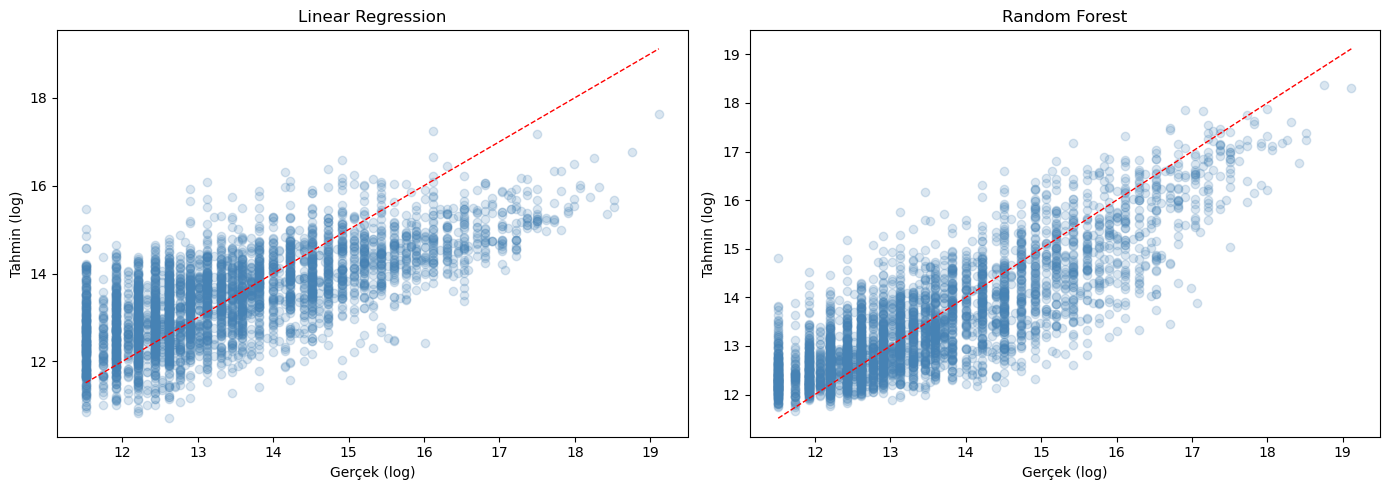

In [26]:
# gerçek ve tahmin karşılaştırma
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ["Linear Regression", "Random Forest"]
):
    ax.scatter(y_test, y_pred, alpha=0.2, color="steelblue")
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], "r--", linewidth=1)
    ax.set_xlabel("Gerçek (log)")
    ax.set_ylabel("Tahmin (log)")
    ax.set_title(title)

plt.tight_layout()
plt.savefig("../visuals/actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

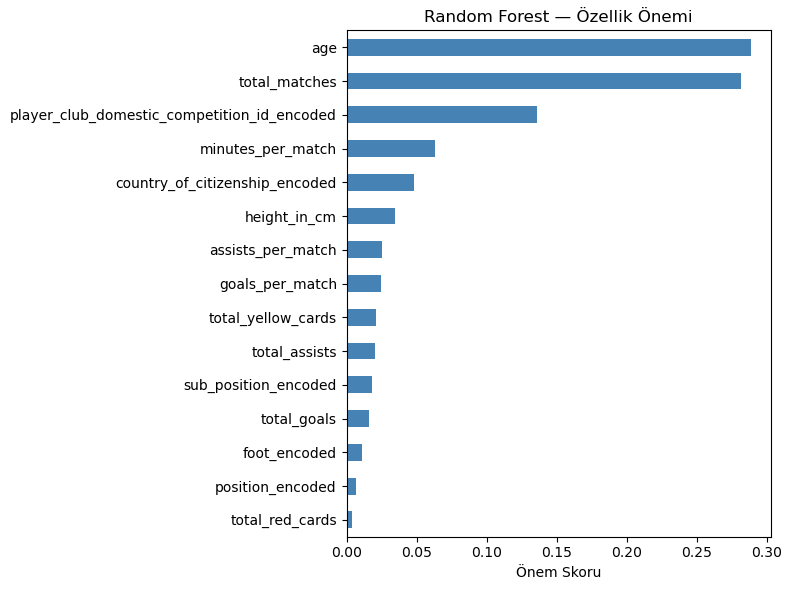

In [27]:
# random forest özellik önemi
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances.plot(kind="barh", color="steelblue")
plt.xlabel("Önem Skoru")
plt.title("Random Forest — Özellik Önemi")
plt.tight_layout()
plt.savefig("../visuals/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Hata Analizi

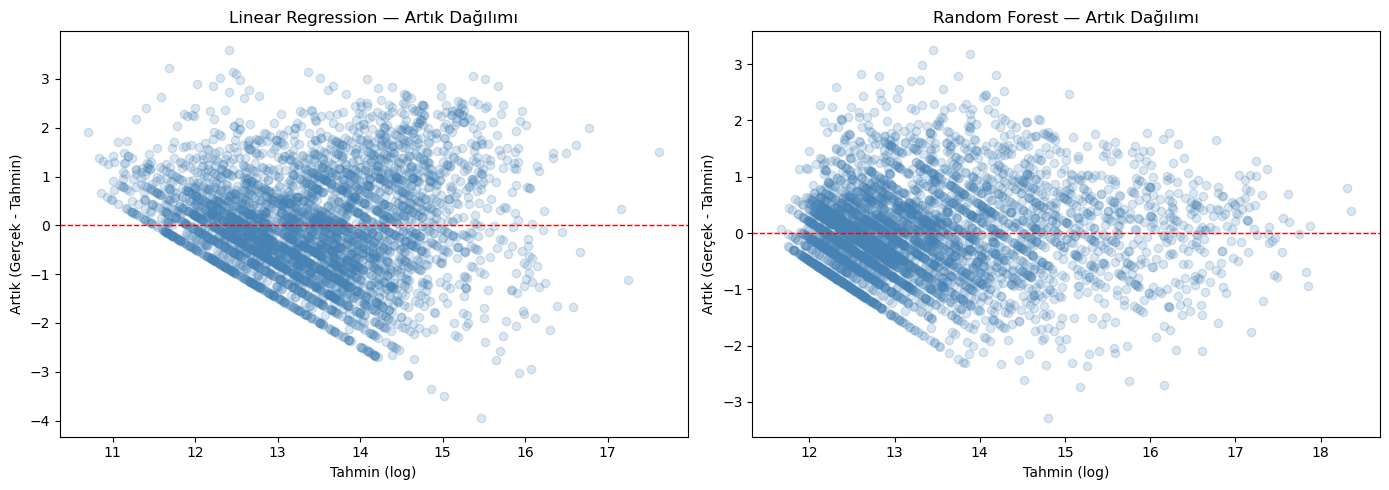

In [28]:
# artık (residual) dağılımı
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ["Linear Regression", "Random Forest"]
):
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.2, color="steelblue")
    ax.axhline(0, color="red", linestyle="--", linewidth=1)
    ax.set_xlabel("Tahmin (log)")
    ax.set_ylabel("Artık (Gerçek - Tahmin)")
    ax.set_title(f"{title} — Artık Dağılımı")

plt.tight_layout()
plt.savefig("../visuals/residuals.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Tahmin Yorumu

In [29]:
# log değerlerini Euro değerine çevirme
y_test_eur = np.expm1(y_test)
y_pred_lr_eur = np.expm1(y_pred_lr)
y_pred_rf_eur = np.expm1(y_pred_rf)

# örnek tahminler
sample = pd.DataFrame({
    "Gerçek (€)": y_test_eur.values[:10],
    "LR Tahmini (€)": y_pred_lr_eur[:10],
    "RF Tahmini (€)": y_pred_rf_eur[:10]
})
sample = sample.map(lambda x: f"{x:,.0f}")
print("\nÖrnek Tahminler:")
print(sample.to_string(index=False))


Örnek Tahminler:
Gerçek (€) LR Tahmini (€) RF Tahmini (€)
   250,000        368,723        312,473
   200,000        348,991        433,173
   100,000        234,841        246,155
   300,000        630,235        300,911
 4,000,000      2,718,595      2,835,850
   500,000      9,560,002        501,844
   100,000         74,073        173,319
   300,000        522,400        376,317
   225,000        590,899        910,521
 2,000,000      1,713,383      1,765,204


In [30]:
# mevkiye göre örnek tahminler
for position in sorted(df["position"].unique()):
    df_pos_all = df[df["position"] == position]
    X_pos_all = df_pos_all[position_features[position]]
    y_pos_all = df_pos_all["log_market_value"]

    _, X_te_pos, _, y_te_pos = train_test_split(
        X_pos_all, y_pos_all, test_size=0.2, random_state=42
    )

    lr_pos_sample = position_models[position]["lr"]
    rf_pos_sample = position_models[position]["rf"]

    pred_lr_eur = np.expm1(lr_pos_sample.predict(X_te_pos[:3]))
    pred_rf_eur = np.expm1(rf_pos_sample.predict(X_te_pos[:3]))
    actual_eur = np.expm1(y_te_pos.values[:3])

    sample_pos = pd.DataFrame({
        "Gerçek (€)": actual_eur,
        "LR Tahmini (€)": pred_lr_eur,
        "RF Tahmini (€)": pred_rf_eur
    }).map(lambda x: f"{x:,.0f}")
    print(f"\n{position}:")
    print(sample_pos.to_string(index=False))


Attack:
Gerçek (€) LR Tahmini (€) RF Tahmini (€)
   500,000        518,605        317,962
 1,000,000        350,496        606,270
 3,500,000      2,324,437      3,945,548

Defender:
Gerçek (€) LR Tahmini (€) RF Tahmini (€)
   200,000      2,122,279        746,824
   100,000        110,135        302,652
   800,000        241,402        318,049

Goalkeeper:
Gerçek (€) LR Tahmini (€) RF Tahmini (€)
 4,000,000        638,425        967,991
   800,000      1,291,161      1,101,158
   200,000        202,658        254,541

Midfield:
Gerçek (€) LR Tahmini (€) RF Tahmini (€)
 3,500,000      3,423,206      3,665,060
35,000,000      4,299,826     20,165,924
   200,000        175,715        173,141


## 12. Bulgular
- Random Forest, tüm metriklerde Linear Regresssion'ı geride bırakmıştır; RMSE 1.05'ten 0.81'e, R² ise 0.48'den 0.69'a yükselmiştir.
- Random Forest modeli varyansın %69'ını açıklamaktadır; bu düzey transfer piyasasındaki öznel etkenler göz önüne alındığında tatmin edici bir performans olarak değerlendirilebilir.
- 5 katlı çapraz doğrulama sonuçları (CV RMSE: 0.7967 ± 0.0213) test seti sonuçlarıyla örtüşmektedir; modelin genelleme kapasitesi güçlüdür ve aşırı öğrenme gözlemlenmemiştir.
- Linear Regression, piyasa değerinin doğrusal olmayan yapısını yeterince yakalayamamış; tahminler özellikle yüksek değerli futbolcularda belirgin sapma göstermiştir.
- Mevkiye göre modelleme sonuçları genel modelle tutarlıdır; Random Forest her mevkide Linear Regression'ı geride bırakmış, en yüksek R² orta saha (0.68), en düşük kaleci (0.63) modelinde gözlemlenmiştir.
- Kaleci modelinin görece düşük performansı, gol ve asist gibi temel performans göstergelerinin bu mevki için anlamsız olmasından kaynaklanmaktadır.
- Artık dağılım analizi, Random Forest'ın hata dağılımının daha dengeli olduğunu ortaya koymaktadır; bununla birlikte her iki modelde de yüksek değerli futbolcularda tahmin güçlüğü gözlemlenmiştir.
- Tahmin yorumu tablosu, Random Forest'ın Euro bazında gerçek değerlere daha yakın sonuçlar ürettiğini somut örneklerle göstermektedir.